In [1]:
import tools as t
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier

In [2]:
df = pd.read_csv("../data/Maildata.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5700 entries, 0 to 5699
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5700 non-null   str  
 1   Message   5700 non-null   str  
dtypes: str(2)
memory usage: 89.2 KB


In [4]:
df[df.duplicated()]

,Category,Message
103,ham,As per your request 'Melle Melle (Oru Minnamin...
154,ham,As per your request 'Melle Melle (Oru Minnamin...
207,ham,"As I entered my cabin my PA said, '' Happy B'd..."
223,ham,"Sorry, I'll call later"
326,ham,No calls..messages..missed calls
...,...,...
5695,ham,I want to send something that can sell fast. ...
5696,ham,"Haha good to hear, I'm officially paid and on ..."
5697,ham,Yes I started to send requests to make it but ...
5698,ham,have got * few things to do. may be in * pub l...


In [4]:
df.drop_duplicates(inplace=True)

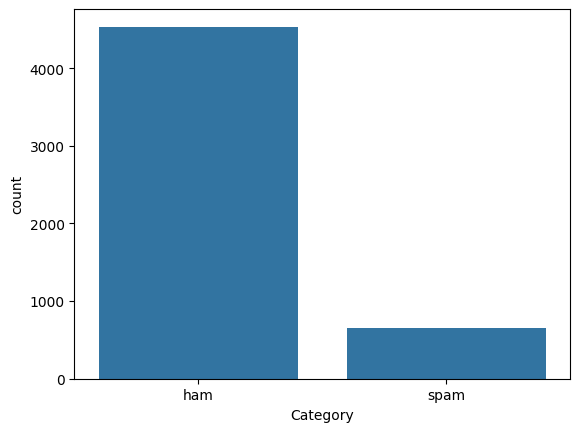

In [6]:
sns.countplot(data=df, x="Category")
plt.show()

In [5]:
df["Category"] = df["Category"].map({"spam": 0, "ham": 1})

In [6]:
df_new = pd.concat([df[df["Category"] == 0], df[df["Category"] == 1].sample(df[df["Category"] == 0].shape[0])], ignore_index=True)

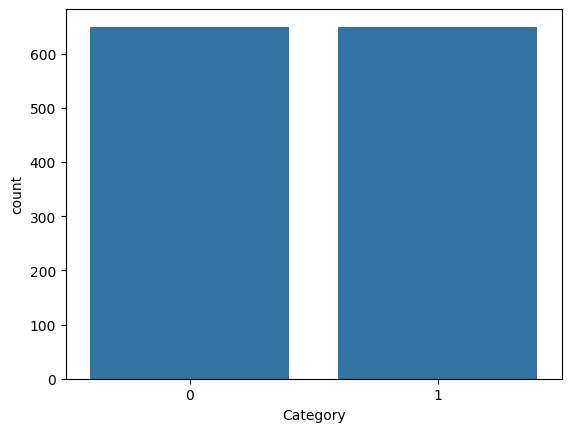

In [9]:
sns.countplot(data=df_new, x="Category")
plt.show()

In [7]:
df = df_new

In [8]:
X, y = t.tokenizing(df, "Message", "Category")

In [9]:
print(X.shape)
print(y.shape)

(1300, 50)
(1300,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=t.TEST_SIZE, random_state=t.RANDOM_STATE, stratify=y, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=t.TEST_SIZE, random_state=t.RANDOM_STATE, stratify=y_test, shuffle=True)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(1040, 50)
(208, 50)
(52, 50)
(1040,)
(208,)
(52,)


In [11]:
estimator = KerasClassifier(model=t.create_model, 
                            epochs=t.CV_EPOCHS, 
                            batch_size=t.BATCH_SIZE)

In [12]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=t.RANDOM_STATE)

In [13]:
results = cross_val_score(estimator, X_train, y_train, cv=kfold)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.4880 - loss: 0.6947
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7728 - loss: 0.4988
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9423 - loss: 0.2123
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9591 - loss: 0.1688
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9171 - loss: 0.2802
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8077 - loss: 0.4466
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8101 - loss: 0.4382
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8137 - loss: 0.4301
Epoch 9/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8149 - loss: 0.4277
Epoch 10/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8149 - loss: 0.4297
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step
Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5625 - loss: 0.6509
Epoch 2/10
26/26 ━━━━━━━━━

In [14]:
print(f"Average accuracy: {results.mean():.3f}")

Average accuracy: 0.895


In [15]:
nlp_model = t.create_model()
early_stopping = EarlyStopping(patience=4,
                               restore_best_weights=True,
                               monitor="val_loss")
main_result = nlp_model.fit(X_train, y_train,
                            validation_data=(X_val, y_val),
                            epochs=t.EPOCHS,
                            batch_size=t.BATCH_SIZE,
                            callbacks=early_stopping)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.5702 - loss: 0.6712 - val_accuracy: 0.8606 - val_loss: 0.4808
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9077 - loss: 0.3143 - val_accuracy: 0.8846 - val_loss: 0.4137
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9365 - loss: 0.2463 - val_accuracy: 0.9087 - val_loss: 0.2882
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9615 - loss: 0.1567 - val_accuracy: 0.9087 - val_loss: 0.3058
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9587 - loss: 0.1549 - val_accuracy: 0.8990 - val_loss: 0.2842
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9788 - loss: 0.0829 - val_accuracy: 0.9183 - val_loss: 0.2834
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9856 - loss: 0.0699 - val_accuracy: 0.9038 - val_loss: 0.3605
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9865 - loss: 0.0697 - val_accuracy: 0.9038 - v

In [16]:
y_pred = (nlp_model.predict(X_test, batch_size=1) > 0.5).astype(int)

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print(f"accuracy: {accuracy:.3f}")
print(f"precision: {precision:.3f}")
print(f"recall: {recall:.3f}")
print(f"f1: {f1:.3f}")
print(f"roc-auc: {auc:.3f}")

accuracy: 0.942
precision: 0.960
recall: 0.923
f1: 0.941
roc-auc: 0.942


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step 


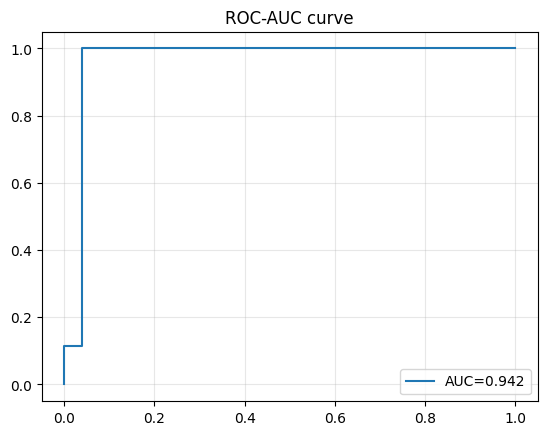

In [18]:
y_pred_proba = nlp_model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.title("ROC-AUC curve")
plt.show()

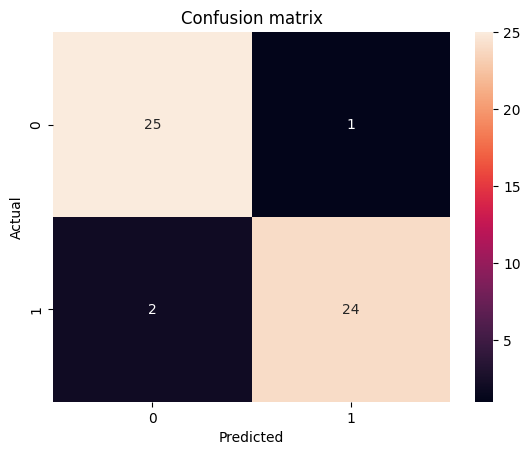

In [19]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

In [27]:
pd.set_option('display.max_colwidth', None)

errors = X_test[y_pred.flatten() != y_test].tolist()
indexes = [X.tolist().index(err) for err in errors]
df.iloc[indexes]

,Category,Message
744,1,yes now only saw your message
461,0,oh my god i ve found your number again i m so glad text me back xafter this msgs cst std ntwk chg
905,1,the word checkmate in chess comes from the persian phrase shah maat which means the king is dead goodmorning have a good day
